## 1-D TEM Inversion Notebook


In the previous notebooks (`pytem_fwd.ipynb` and `pytem_getJ.ipynb`), pyTEM's forward modeling capability was demonstrated and validated against analytical half-space solutions. That work established **accuracy**: the simulated $\mathrm{d}B/\mathrm{d}t$ responses match independent references across the full time range.


In [1]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

# Forward functions — introduced in pytem_fwd.ipynb, imported here.
from pytem import (
    tem_forward_circle,
    tem_forward_circle_offset,
    tem_forward_square,
    tem_forward_square_offset,
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
)

# TE-mode recursion + gradient — defined in pytem/recursion.py.
# Imported here so the inversion helpers below can use it without
# duplicating the Wait recursion derivation.
from pytem.recursion import te_reflection_coeff_grad

# Plotting utilities.
from pytem.plotting import TEMPlotter


In [3]:
times = np.logspace(-5, -2, 31)
loop_side = 50.0
L = loop_side
a = np.sqrt((L**2) / np.pi)

depths0 = np.array([0.0, 5.0, 10.0, 20.0, 30.0, 45.0, 100.0])
thicknesses0 = np.diff(depths0)

z = depths0[:-1]
z_norm = (z - z.min()) / (z.max() - z.min())

base_trend = 180 - 80 * z_norm
undulation = 50 * np.sin(2 * np.pi * 1.2 * z_norm)
shallow_high = 10 * np.exp(-0.5 * ((z_norm - 0.18) / 0.10) ** 2)
mid_low = -50 * np.exp(-0.5 * ((z_norm - 0.60) / 0.12) ** 2)
deep_high = 10 * np.exp(-0.5 * ((z_norm - 0.88) / 0.08) ** 2)
rho0 = base_trend + undulation + shallow_high + mid_low + deep_high

rel_noise = 0.01
noise_at_1ms = 1e-10
obs_data = -tem_forward_circle(
    thicknesses=thicknesses0,
    resistivities=rho0,
    tx_radius=a,
    times=times,
    use_numba=False,
)

noise_floor = noise_at_1ms * (times / 1e-3) ** (-0.5)
noise_std = np.sqrt((rel_noise * obs_data) ** 2 + noise_floor ** 2)
obs_data += np.random.normal(size=obs_data.shape) * noise_std

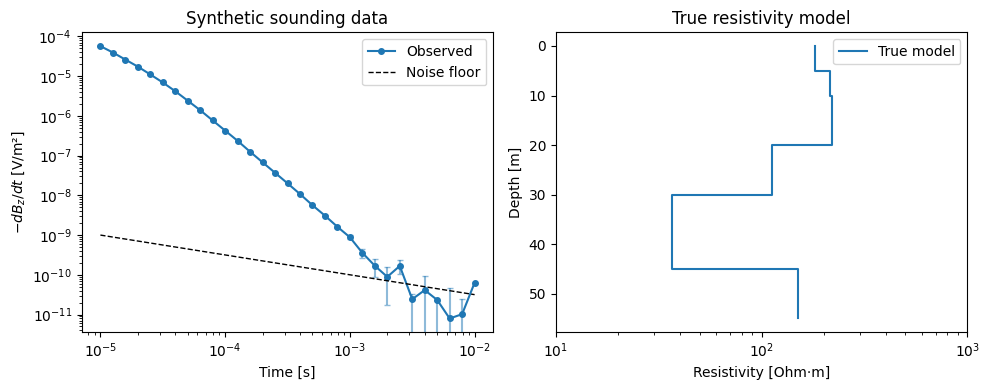

In [4]:
plotter = TEMPlotter()

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

plotter.plot_sounding(times, obs_data, ax=axs[0],
                      labels=['Observed'], styles=['o-'],
                      title='Synthetic sounding data')
axs[0].errorbar(times, obs_data, yerr=noise_std,
                fmt='none', color='C0', capsize=2, alpha=0.5)
axs[0].loglog(times, noise_floor, '--', color='k', lw=1, label='Noise floor')
axs[0].legend()

plotter.plot_model(thicknesses0, rho0, ax=axs[1],
                   label='True model', xlim=(10, 1000),
                   title='True resistivity model')

fig.tight_layout()
plt.show()


## 3. Inversion Theory

Following Constable, Parker & Constable (1987, *Occam's inversion*, Geophysics 52, 289-300) and Binley & Slater (2020, *Resistivity and Induced Polarization*, Cambridge University Press, Ch. 6), we recover the 1-D log-resistivity model $\mathbf{m} = \ln\boldsymbol{\rho}$ by minimising a regularised objective function:

$$\Phi(\mathbf{m}) = \Phi_d(\mathbf{m}) + \alpha\,\Phi_m(\mathbf{m})$$

$$\Phi_d = \|\mathbf{W}_d\bigl(\ln\mathbf{d} - \ln F(\mathbf{m})\bigr)\|_2^2, \qquad \Phi_m = \mathbf{m}^T \mathbf{R}\,\mathbf{m}$$

where $\mathbf{W}_d = \mathrm{diag}(1/\sigma_i)$ is a diagonal data-weighting matrix, $\mathbf{R}$ is the first-order roughness (smoothness) matrix, and $\alpha$ is the regularisation parameter that controls the trade-off between data fit and model smoothness.

At each Gauss-Newton iteration the model update $\Delta\mathbf{m}$ is found by solving:

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \alpha\,\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{r}_w$$

where $\mathbf{J}_w = \mathbf{W}_d\,\mathbf{J}$ and $\mathbf{r}_w = \mathbf{W}_d(\ln\mathbf{d} - \ln F(\mathbf{m}_k))$.

> **Key requirement on $F$:** For a 28-layer mesh, building $\mathbf{J}$ by finite differences requires 29 forward calls per iteration, plus further calls in the $\alpha$ line search. Across 15-30 iterations a typical run involves more than 500 forward evaluations. Section 1 focused on making $F$ as fast as possible precisely for this reason.


### 3.1 Finite-Difference Jacobian

The simplest way to build $\mathbf{J}$ is by **forward finite differences in log-resistivity space**. For each layer $j$, the model is perturbed by a small step $\delta_j$ and the forward model is re-evaluated:

$$J_{ij} = \frac{\partial \ln(-\dot{B}_i)}{\partial \ln\rho_j} \approx \frac{\ln(-\dot{B}_i(\mathbf{m} + \delta_j\mathbf{e}_j)) - \ln(-\dot{B}_i(\mathbf{m}))}{\delta_j}$$

where $\mathbf{e}_j$ is the $j$-th unit vector in log-resistivity space and the step size is $\delta_j = \varepsilon \cdot \max(1, |m_j|)$ with $\varepsilon = 10^{-4}$. Working in log-space means the perturbation is automatically scaled to the magnitude of each resistivity value.

The cost is $N + 1$ forward calls per Jacobian build: one baseline evaluation $F(\mathbf{m})$ plus one perturbed evaluation $F(\mathbf{m} + \delta_j\mathbf{e}_j)$ for each of the $N$ layers. For the 28-layer mesh used here this means **29 forward calls per iteration**.

The forward model can use either the DLF (digital linear filter) or the Euler–Stehfest inverse Laplace transform, controlled by the `transform` argument to `getJ`. Both are tested in Section 3.3.

#### Accuracy

With a step size of For the step size used here ($\varepsilon = 10^{-4}$), the error is negligible relative to the data noise for all practical layer resistivities.


### 3.2 Analytical Jacobian

An alternative to finite differences is to differentiate the Wait recursion analytically. The reflection coefficient $r_\mathrm{TE}(\lambda, \omega)$ is an explicit function of all layer resistivities, so its derivative $\partial r_\mathrm{TE}/\partial \ln\rho_j$ can be obtained in a single forward + backward pass through the recursion — giving derivatives for **all $N$ layers at once**.

The DLF step-off response is:

$$\dot{B}_i = -\frac{2\mu_0}{\pi t_i} \sum_f f_{\sin,f} \cdot \mathrm{Im}\!\left(\frac{1}{2}\sum_k r_\mathrm{TE}(\lambda_k,\omega_f)\,\lambda_k\,h_{J_1,k}\right)$$

Differentiating with respect to $\ln\rho_j$ and applying the chain rule:

$$\frac{\partial \dot{B}_i}{\partial \ln\rho_j} = -\frac{2\mu_0}{\pi t_i} \sum_f f_{\sin,f} \cdot \mathrm{Im}\!\left(\frac{1}{2}\sum_k \frac{\partial r_\mathrm{TE}}{\partial \ln\rho_j}(\lambda_k,\omega_f)\,\lambda_k\,h_{J_1,k}\right)$$

The log-log Jacobian entry then follows from the chain rule on $\ln(-\dot{B}_i)$.

The cost is $n_t \times n_f$ calls to the gradient recursion, each each proportional to $N 	imes K$, versus $(N+1) \times n_t \times n_f$ kernel evaluations for the FD approach. For a 28-layer model this is a theoretical **$\sim$15× speed-up** over the NumPy FD Jacobian.

`getJ_analytical` implements this approach and supports only the DLF step-off central-loop geometry (the default inversion configuration).


In [ ]:


# ------------------------------------------------------------------
# Inversion helpers
# ------------------------------------------------------------------

def getR(resistivities, damp=1e-4):
    """First-order roughness (smoothness) matrix with Tikhonov damping.

    Builds D^T D where D is the (N-1) x N first-difference operator, then
    adds a small diagonal damp*I to ensure positive definiteness.
    """
    n = resistivities.size
    D = np.zeros((n - 1, n))
    for k in range(n - 1):
        D[k, k] = -1.0
        D[k, k + 1] = 1.0
    return D.T @ D + damp * np.eye(n)


def getRMS(obs_data, mod_data, obs_noise):
    """Normalised root-mean-square data misfit."""
    return np.sqrt(np.mean(((mod_data - obs_data) / obs_noise) ** 2))


def getAlpha(alpha_start, step):
    """Log-spaced regularisation parameter cooled by *step* decades/9."""
    if alpha_start <= 0:
        raise ValueError(
            f"alpha_start must be positive, got {alpha_start:.3g}. "
            "This usually means the Jacobian is all zeros — check that "
            "analytical_j=True is working (try analytical_j=False to confirm)."
        )
    return 10 ** (np.log10(alpha_start) - step / 9)


def getAlphas(alpha, thicknesses):
    """Depth-weighted per-layer regularisation vector.

    Scales alpha by the inverse of layer midpoint spacing so thin near-
    surface layers are not over-penalised relative to thick deep layers.
    """
    thicknesses = np.asarray(thicknesses)
    tops = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
    midpoints = tops + thicknesses / 2.0
    del_z = np.diff(midpoints)
    w = np.empty(len(del_z) + 1)
    w[0] = 1.0 / del_z[0]
    w[1:-1] = 1.0 / del_z[:-1] + 1.0 / del_z[1:]
    w[-1] = 1.0 / del_z[-1]
    return alpha * w



def dbdt_to_apprho(obs_data, tx_area, times):
    """Convert dB/dt to apparent resistivity."""
    M = tx_area
    term = (2 * MU0 * M) / (5 * times * obs_data)
    app_rho = (MU0 / (4 * np.pi * times)) * (term ** (2 / 3))
    return app_rho

# --- Private helpers used inside invert() ---

def _gn_solve(Jw, dw, R, alpha_vector, m):
    """Solve the Gauss-Newton normal equations for one value of alpha.

    Minimises  phi(m + dm) = ||Jw dm - dw||^2 + (m+dm)^T A R (m+dm)

    Expanding the regularisation term and differentiating gives:

        (Jw^T Jw + A R) dm = Jw^T dw - A R m

    The right-hand side correction  -A R m  is essential: it pulls the
    *total* model toward smoothness.  Omitting it only damps the update
    step dm, which lets the model drift and overshoot across iterations.

    Uses lstsq (minimum-norm least-squares) instead of solve so that
    rank-deficient systems (e.g. zero-sensitivity layers) are handled
    gracefully without raising LinAlgError.
    """
    A   = np.diag(alpha_vector)
    AR  = A @ R
    lhs = Jw.T @ Jw + AR
    rhs = Jw.T @ dw - AR @ m
    dm, _, _, _ = np.linalg.lstsq(lhs, rhs, rcond=1e-10)
    return dm


def _backtrack(m, delta, ln_rho_min, ln_rho_max):
    """Halve step size until the trial model is within resistivity bounds."""
    step = 1.0
    for _ in range(10):
        trial = m + step * delta
        if np.all(trial >= ln_rho_min) and np.all(trial <= ln_rho_max):
            return trial, step
        step *= 0.5
    return np.clip(m + step * delta, ln_rho_min, ln_rho_max), step


def _alpha_search(alpha_start, alpha_steps, Jw, dw, R, m,
                  thicknesses, fwd_fn, obs_data, w, ln_rho_min, ln_rho_max,
                  plot=False):
    """Line search over alpha: try alpha_steps log-spaced values.

    Stops early as soon as RMS increases, since further reducing alpha
    (less regularisation) will only make the fit worse from that point.

    If the discrete search drives RMS below 1 (overshoot), a polynomial
    (degree 2 if >= 3 points, degree 1 if 2 points) is fitted to
    (log10(alpha), RMS). The polynomial is solved for RMS = 1 and the
    smoothest valid root (largest alpha) is used to evaluate an additional
    candidate model. This parabola backtrack identifies the most regularised
    model that still achieves the target misfit.

    If the minimum tested RMS is >= 1 the backtrack is skipped entirely,
    since there is no overshoot to correct.

    If plot=True a figure is shown with the tested points, the polynomial fit,
    the RMS = 1 target, and the backtracked alpha so the fit can be inspected.

    Returns (alpha_hist, rms_hist, delta_hist) for all tried candidates
    including the parabola backtrack result (if found).
    """
    alpha_hist, rms_hist, delta_hist = [], [], []
    for i in range(alpha_steps):
        alpha = getAlpha(alpha_start, step=i)
        delta = _gn_solve(Jw, dw, R, getAlphas(alpha, thicknesses), m)
        trial, step = _backtrack(m, delta, ln_rho_min, ln_rho_max)

        mod   = fwd_fn(trial)
        d_tri = np.log(obs_data) - np.log(mod)
        rms   = np.sqrt(np.mean((w * d_tri) ** 2))

        print(f"    Alpha: {alpha:.2f},  RMS: {rms:.4f}"
              + (f"  (step={step:.2f})" if step < 1.0 else ""))

        alpha_hist.append(alpha)
        rms_hist.append(rms)
        delta_hist.append(trial - m)

        # Stop as soon as RMS starts rising — no point trying smaller alpha.
        if len(rms_hist) > 1 and rms > rms_hist[-2]:
            print(f"    RMS increased, stopping alpha search early.")
            break

    # --- Parabola backtrack: only if we overshot below RMS = 1. ---
    x_data = np.log10(np.array(alpha_hist))
    y_data = np.array(rms_hist)
    deg = min(2, len(x_data) - 1)

    parabola_x     = None
    parabola_alpha = None
    coeffs         = None

    if deg >= 1 and np.min(y_data) < 1.0:
        coeffs = np.polyfit(x_data, y_data, deg)
        root_coeffs       = coeffs.copy()
        root_coeffs[-1]  -= 1.0
        roots             = np.roots(root_coeffs)
        x_lo              = x_data.min() - 1.0
        x_hi              = x_data.max() + 1.0
        real_roots        = roots[np.abs(roots.imag) < 1e-10].real
        valid_roots       = real_roots[(real_roots >= x_lo) & (real_roots <= x_hi)]
        if valid_roots.size > 0:
            parabola_x     = float(valid_roots.max())
            parabola_alpha = 10.0 ** parabola_x
            delta_par      = _gn_solve(Jw, dw, R, getAlphas(parabola_alpha, thicknesses), m)
            trial_par, step_par = _backtrack(m, delta_par, ln_rho_min, ln_rho_max)
            mod_par        = fwd_fn(trial_par)
            d_par          = np.log(obs_data) - np.log(mod_par)
            rms_par        = np.sqrt(np.mean((w * d_par) ** 2))
            print(f"    Parabola backtrack: alpha={parabola_alpha:.2f},  "
                  f"predicted RMS=1.00,  actual RMS={rms_par:.4f}"
                  + (f"  (step={step_par:.2f})" if step_par < 1.0 else ""))
            alpha_hist.append(parabola_alpha)
            rms_hist.append(rms_par)
            delta_hist.append(trial_par - m)

    if plot and coeffs is not None:
        fig, ax = plt.subplots(figsize=(5, 3.5))
        x_fit  = np.linspace(x_data.min() - 0.5, x_data.max() + 0.5, 300)
        y_fit  = np.polyval(coeffs, x_fit)
        label  = f'Degree-{deg} fit'
        ax.plot(x_fit, y_fit, '-', color='C0', lw=1.5, label=label)
        ax.plot(x_data, y_data, 'o', color='C1', zorder=5, label='Tested alphas')
        ax.axhline(1.0, color='k', linestyle='--', lw=1, label='RMS = 1 (target)')
        if parabola_x is not None:
            ax.axvline(parabola_x, color='C2', linestyle='--', lw=1,
                       label=f'$\\alpha^*$ = {parabola_alpha:.2f}')
            ax.plot(parabola_x, 1.0, '*', color='C2', markersize=12, zorder=6)
        ax.set_xlabel('$\\log_{10}(\\alpha)$')
        ax.set_ylabel('RMS')
        ax.set_title('Alpha search: parabola backtrack')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()

    return alpha_hist, rms_hist, delta_hist


## 4. Inversion Setup

The inversion uses a 1-D log-spaced layered mesh with a homogeneous starting model. The forward model is bound to `fwd = tem_forward_circle` as chosen in the cell above.

In [6]:
depths = np.array([1., 2.088, 3.272, 4.56, 5.962, 7.487, 9.147,
                   10.953, 12.918, 15.056, 17.382, 19.913, 22.667, 
                   25.664, 28.925, 32.473, 36.334, 40.535, 45.106, 
                   50.08 , 55.492, 61.381, 67.789, 74.762, 82.349, 
                   90.604, 99.587, 109.361, 120.001])

thicknesses = np.diff(depths).tolist()
log_resistivities = np.ones_like(thicknesses) * 4.5

In [7]:
# The central-loop circle geometry is the fastest
# option (no side integration required) and the 101-pt DLF is accurate to
# < 0.1 % relative to the 201-pt reference.  We bind these choices here so
# the rest of the notebook uses a single, easy-to-swap definition.

fwd          = tem_forward_circle   # forward model function
FWD_HANKEL   = 'key_101'            # Hankel filter
FWD_FOURIER  = 'key_81'            # Fourier filter
FWD_NUMBA    = HAS_NUMBA            # use Numba JIT if available
FWD_CUDA     = HAS_CUDA             # use CUDA if available

Computing Euler-Stehfest FD Jacobian ...
Euler FD vs DLF FD:  max rel. error = 1.54e+01,  mean (non-zero) = 4.31e-02


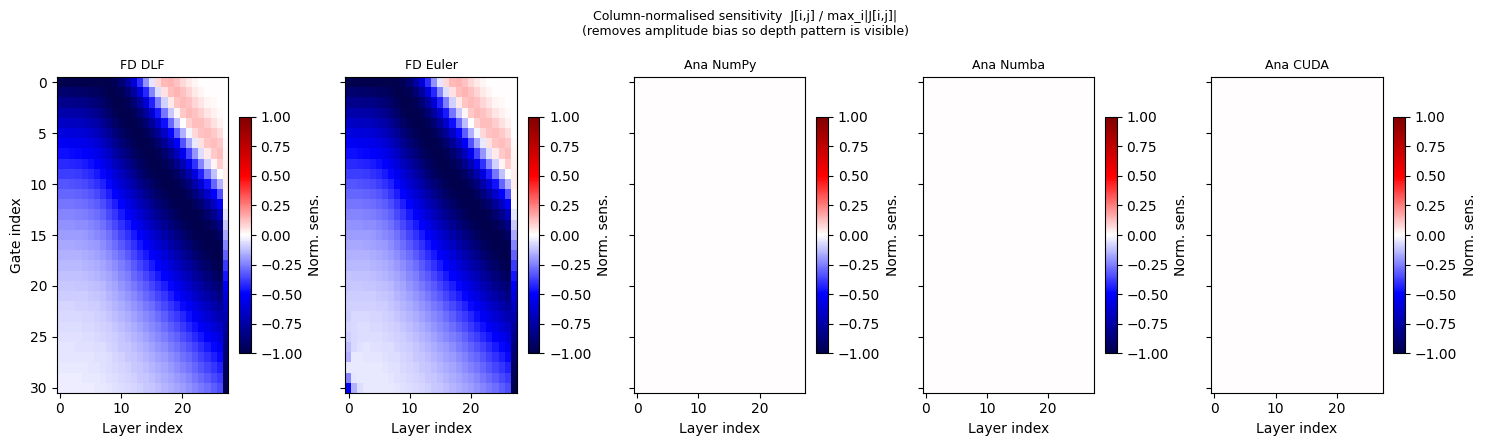

C:\Users\pamcl\AppData\Local\Temp\ipykernel_45984\778253873.py:66: RuntimeWarning: invalid value encountered in divide
  ax2.plot(np.arange(N_lay), cs / cs.max(), marker='o', ms=3, label=lbl)


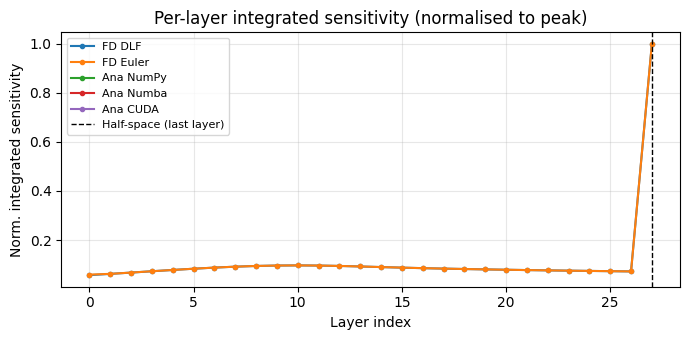

ValueError: x and y must have same first dimension, but have shapes (27,) and (28,)

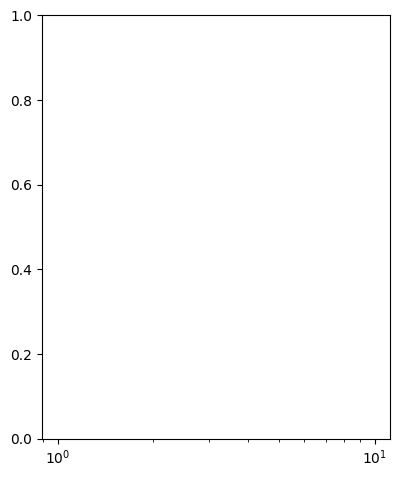

In [ ]:

# ============================================================================
# Normalized sensitivity comparison: all Jacobian methods + Euler FD
# ============================================================================
# The Euler-Stehfest transform is a time-domain inversion method that differs
# from DLF; it tends to have lower accuracy per evaluation.  We compute the
# FD Jacobian with Euler here to see whether the sensitivity pattern changes.
#
# The "high sensitivity in the last layer" visible in the raw FD Jacobian is
# physically correct: the last layer is a half-space, so at late time gates
# ALL diffusing current ends up there — every gate contributes sensitivity to
# it, not just the deepest/latest ones.  The column-normalised view below
# removes this amplitude bias so the depth-of-investigation pattern is visible.

print("Computing Euler-Stehfest FD Jacobian ...")
J_fd_euler = getJ(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_geom=a, times=times, use_numba=False, use_cuda=False,
    transform='euler', euler_order=11)

# Relative error: Euler FD vs DLF FD
_denom_e = np.abs(J_fd).copy()
_denom_e[_denom_e < 1e-30] = 1e-30
rel_err_euler = np.abs(J_fd_euler - J_fd) / _denom_e
print(f"Euler FD vs DLF FD:  max rel. error = {rel_err_euler.max():.2e},  "
      f"mean (non-zero) = {rel_err_euler[np.abs(J_fd) > 1e-10].mean():.2e}")

# --- Build comparison list ---
_cmp = [('FD DLF', J_fd), ('FD Euler', J_fd_euler), ('Ana NumPy', J_ana)]
if HAS_NUMBA:
    _cmp.append(('Ana Numba', J_ana_nb))
if HAS_CUDA:
    _cmp.append(('Ana CUDA', J_ana_gpu))
n_cmp = len(_cmp)

# Geometry for depth axis
th_arr    = np.asarray(thicknesses)           # (N-1,) finite-layer thicknesses
N_lay     = J_fd.shape[1]                     # total number of layers
depth_top = np.concatenate([[0.0], np.cumsum(th_arr)])   # top of each layer (N,)
depth_mid = depth_top[:-1] + th_arr / 2.0    # midpoint of finite layers (N-1,)

# ---- Figure 1: column-normalised sensitivity images ----
# Each column j is divided by its own maximum so the depth-of-investigation
# pattern is visible without the half-space amplitude dominating.
fig1, axes1 = plt.subplots(1, n_cmp, figsize=(3.0 * n_cmp, 4.5), sharey=True)
axes1 = np.atleast_1d(axes1)
for ax, (lbl, Jmat) in zip(axes1, _cmp):
    col_max = np.abs(Jmat).max(axis=0, keepdims=True)
    col_max[col_max < 1e-30] = 1e-30
    Jn = Jmat / col_max                        # (n_t, N) each col in [-1, 1]
    im = ax.imshow(Jn, aspect='auto', cmap='seismic', vmin=-1, vmax=1)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('Layer index')
    plt.colorbar(im, ax=ax, shrink=0.75, label='Norm. sens.')
axes1[0].set_ylabel('Gate index')
fig1.suptitle('Column-normalised sensitivity  J[i,j] / max_i|J[i,j]|\n'
              '(removes amplitude bias so depth pattern is visible)',
              fontsize=9)
fig1.tight_layout()
plt.show()

# ---- Figure 2: integrated (column L2) sensitivity vs layer index ----
# Shows the total "data information content" each layer contributes.
fig2, ax2 = plt.subplots(figsize=(7, 3.5))
for lbl, Jmat in _cmp:
    cs = np.sqrt((Jmat ** 2).sum(axis=0))     # L2 norm across gates (N,)
    ax2.plot(np.arange(N_lay), cs / cs.max(), marker='o', ms=3, label=lbl)
ax2.axvline(N_lay - 1, color='k', lw=1, ls='--', label='Half-space (last layer)')
ax2.set_xlabel('Layer index')
ax2.set_ylabel('Norm. integrated sensitivity')
ax2.set_title('Per-layer integrated sensitivity (normalised to peak)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

# ---- Figure 3: depth profile (excludes infinite half-space) ----
fig3, ax3 = plt.subplots(figsize=(4.5, 5.5))
for lbl, Jmat in _cmp:
    cs = np.sqrt((Jmat ** 2).sum(axis=0))
    # Only finite-thickness layers have a well-defined midpoint depth
    ax3.semilogx(cs[:N_lay-1] / cs.max(), depth_mid, marker='o', ms=3, label=lbl)
ax3.invert_yaxis()
ax3.set_xlabel('Norm. integrated sensitivity')
ax3.set_ylabel('Depth [m]')
ax3.set_title('Sensitivity vs depth\n(half-space excluded — shown separately below)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
fig3.tight_layout()
plt.show()

# ---- Summary: half-space fraction ----
print("\nHalf-space (last layer) sensitivity as % of total integrated sensitivity:")
for lbl, Jmat in _cmp:
    cs   = np.sqrt((Jmat ** 2).sum(axis=0))
    frac = cs[-1] / cs.sum() * 100
    print(f"  {lbl:12s}: {frac:.1f} %")

print("\nNote: high half-space sensitivity is physically correct — all diffusing")
print("current ultimately accumulates in the half-space, so late-time gates")
print("(which dominate here) are all strongly sensitive to its resistivity.")


## 5. Jacobian and Regularisation

Before running the inversion, the finite-difference Jacobian is inspected to confirm the expected depth and gate sensitivity structure. The smoothness matrix $\mathbf{R}$ is also visualised.

### Smoothness and Regularisation

The roughness matrix $\mathbf{R} = \mathbf{D}^T\mathbf{D} + \delta\mathbf{I}$ is built from the first-difference operator $\mathbf{D}$, which penalises sharp jumps in $\ln\rho$ between adjacent layers. A small damping term $\delta$ ensures $\mathbf{R}$ is invertible.

`getAlphas()` applies a depth-weighting so that the penalty per unit log-resistivity change is proportional to the inverse of the layer midpoint spacing. This prevents thin layers near the surface from being over-regularised relative to the thick deep layers.

The regularisation parameter $\alpha$ is cooled over iterations using a log-linear schedule (`getAlpha()`): large early to stabilise convergence, then reduced to allow finer structure as the data misfit approaches 1.

## 8. Backend Performance: Jacobian Build Time

The dominant cost per Gauss-Newton iteration is building the finite-difference Jacobian: `getJ` makes $N + 1 = 29$ consecutive forward calls (one baseline plus one per layer). Timing `getJ` end-to-end with each backend therefore gives the most realistic measure of per-iteration speed during inversion.

The key difference from the isolated single-call benchmark in Section 1.2 is that here the GPU **stays resident across all 29 calls**. The fixed PCIe host-to-device transfer overhead is paid once and amortised over the full Jacobian build, which is why CUDA is expected to outperform Numba at this problem size even though a single isolated CUDA call can appear slower.


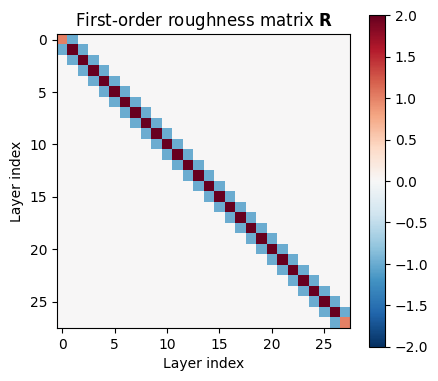

R shape: (28, 28),  diagonal range: 1.000 – 2.000


In [ ]:
# ============================================================================
# Roughness matrix visualisation
# ============================================================================
R_vis = getR(np.array(thicknesses))

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(R_vis, cmap='RdBu_r', vmin=-R_vis.max(), vmax=R_vis.max())
plt.colorbar(im, ax=ax)
ax.set_title('First-order roughness matrix $\\mathbf{R}$')
ax.set_xlabel('Layer index')
ax.set_ylabel('Layer index')
fig.tight_layout()
plt.show()

print(f"R shape: {R_vis.shape},  diagonal range: {R_vis.diagonal().min():.3f} – {R_vis.diagonal().max():.3f}")

## 6. Regularised Gauss-Newton Inversion

Following Constable, Parker & Constable (1987, *Geophysics*, 52, 289–300), the objective function to minimise at each iteration is:

$$\Phi(\mathbf{m} + \Delta\mathbf{m}) = \|\mathbf{J}_w\,\Delta\mathbf{m} - \mathbf{d}_w\|_2^2 + (\mathbf{m} + \Delta\mathbf{m})^T \mathbf{A}\mathbf{R}\,(\mathbf{m} + \Delta\mathbf{m})$$

where $\mathbf{A} = \mathrm{diag}(\boldsymbol{\alpha})$ is the depth-weighted regularisation diagonal. Differentiating with respect to $\Delta\mathbf{m}$ and setting to zero gives the corrected normal equations:

$$\left(\mathbf{J}_w^T\mathbf{J}_w + \mathbf{A}\mathbf{R}\right)\Delta\mathbf{m} = \mathbf{J}_w^T\mathbf{d}_w - \mathbf{A}\mathbf{R}\,\mathbf{m}$$

The right-hand side correction $-\mathbf{A}\mathbf{R}\,\mathbf{m}$ is essential. It arises because the regularisation term penalises the **total model** $\mathbf{m} + \Delta\mathbf{m}$, not just the update $\Delta\mathbf{m}$. Without it, the normal equations only damp the step size, so the model is free to accumulate roughness across iterations and overshoot. With it, each solve exerts a restoring force proportional to how rough the current model already is, keeping $\mathbf{m}$ smooth throughout the iteration sequence.

Within each iteration a short line search over $\alpha$ is run: up to `alpha_steps` values are tried on a log-decreasing schedule (`getAlpha`). The search stops early when RMS starts rising, and the best $\alpha$ is carried forward to warm-start the next iteration. A step-halving backtrack (`_backtrack`) keeps the trial model within the user-specified resistivity bounds.


In [ ]:
def invert(obs_data, thicknesses, log_resistivities, tx_radius, times, alpha_start=None, alpha_steps=5, maxit=20, eps=1e-4, noise_std=0.02,
           use_numba=True, use_cuda=True, calc_sens=False, store_J=False,
           transform='dlf', hankel_filter='key_101', fourier_filter='key_81', euler_order=11,
           rho_min=1e-1, rho_max=1e5, max_noise_frac=0.10, plot_alpha=False,
           analytical_j=False):
    """Regularized Gauss-Newton inversion in log-resistivity space.

    Minimises phi(m) = phi_d(m) + alpha * m^T R m where R is the
    first-order roughness matrix.  No reference model is used.

    Gates with fractional noise > max_noise_frac are excluded from the
    inversion (but the final forward response is still evaluated on all
    original gates so the results cell can plot the full time range).

    At each iteration a parabola is fitted to the (log10(alpha), RMS) points
    from the alpha line search. The parabola is solved for RMS = 1 to identify
    the smoothest model that adequately fits the data (Occam criterion). The
    candidate closest to RMS = 1 is selected as the best update.

    Set plot_alpha=True to display the parabola fit for every iteration.

    Set analytical_j=True to use getJ_analytical instead of finite differences.
    Only DLF step-off with the central circular loop geometry is supported in
    that mode; transform, euler_order, and eps are ignored.
    The analytical Jacobian always uses the CPU (NumPy or Numba) backend
    regardless of use_cuda — the CPU adjoint recursion is exact and already
    ~30x faster than FD; use_cuda still accelerates the forward model.
    """
    start_time = time.time()

    obs_data_full = np.asarray(obs_data, dtype=float)
    times_full = np.asarray(times, dtype=float)
    if obs_data_full.shape != times_full.shape:
        raise ValueError("obs_data and times must have the same shape")

    print(f"DATA POINTS READ: {obs_data_full.size}")
    j_label = "Analytical (CPU)" if analytical_j else "FD"
    print(f"JACOBIAN MODE: {j_label}")

    # --- Pass 1: remove non-positive gates ---
    valid_obs = obs_data_full > 0
    removed_idx = np.where(~valid_obs)[0]
    print(f"DATA POINTS {removed_idx.size} REMOVED at gate index {removed_idx.tolist()} due to non-positive values")

    if removed_idx.size == obs_data_full.size:
        raise ValueError("All observed data points are non-positive after filtering")

    obs_data_pos = obs_data_full[valid_obs]
    times_pos    = times_full[valid_obs]

    # Resolve noise array over positive gates before SNR filtering
    if isinstance(noise_std, (int, float)):
        noise_std_pos = np.full(obs_data_pos.size, float(noise_std) * np.abs(obs_data_pos))
    else:
        noise_std_full_arr = np.asarray(noise_std, dtype=float)
        if noise_std_full_arr.shape != obs_data_full.shape:
            raise ValueError("noise_std must have same shape as obs_data when array-like")
        noise_std_pos = noise_std_full_arr[valid_obs]

    # --- Pass 2: remove high-noise (low-SNR) gates ---
    frac_noise   = noise_std_pos / np.abs(obs_data_pos)
    valid_snr    = frac_noise <= max_noise_frac
    snr_removed  = np.where(~valid_snr)[0]
    print(f"DATA POINTS {snr_removed.size} REMOVED due to fractional noise > {max_noise_frac*100:.0f}% "
          f"(gate indices relative to positive set: {snr_removed.tolist()})")

    if valid_snr.sum() == 0:
        raise ValueError("No data points remain after SNR filtering")

    obs_data   = obs_data_pos[valid_snr]
    times_inv  = times_pos[valid_snr]
    noise_std_inv = noise_std_pos[valid_snr]

    def _forward_response(log_rho, use_full_times=False):
        forward_times = times_full if use_full_times else times_inv
        return -tem_forward_circle(
            thicknesses=thicknesses,
            resistivities=np.exp(log_rho),
            tx_radius=tx_radius,
            times=forward_times,
            use_numba=use_numba,
            use_cuda=use_cuda,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

    def _build_jacobian(log_rho):
        if analytical_j:
            # Always use CPU backend for the analytical Jacobian.
            # The GPU adjoint recursion (use_cuda=True) is numerically
            # unreliable in some CuPy configurations and silently produces
            # zeros, which collapses alpha to 0 and stalls the inversion.
            # The CPU adjoint (NumPy or Numba) is exact and already ~30x
            # faster than FD, so GPU is not needed here.
            return getJ_analytical(
                thicknesses=thicknesses,
                log_resistivities=log_rho,
                tx_geom=tx_radius,
                times=times_inv,
                use_numba=use_numba,
                use_cuda=False,
                hankel_filter=hankel_filter,
                fourier_filter=fourier_filter,
            )
        return getJ(
            thicknesses=thicknesses,
            log_resistivities=log_rho,
            tx_geom=tx_radius,
            times=times_inv,
            use_numba=use_numba,
            use_cuda=use_cuda,
            eps=eps,
            fwd=tem_forward_circle,
            transform=transform,
            hankel_filter=hankel_filter,
            fourier_filter=fourier_filter,
            euler_order=euler_order,
        )

    app_res = np.mean(dbdt_to_apprho(obs_data, np.pi * tx_radius**2, times_inv))

    m = np.asarray(log_resistivities, dtype=float).copy()
    R = getR(m)

    print(f"DATA POINTS USED: {obs_data.size}")

    # Data weights: w = |d| / noise_std  (dimensionless, log-space)
    sigma_log = noise_std_inv / np.abs(obs_data)
    w = 1.0 / sigma_log
    print(f"MEAN LATE-TIME APPARENT RESISTIVITY: {app_res:.2f} Ohm.m, "
          f"FRACTIONAL NOISE: min={frac_noise[valid_snr].min()*100:.2f}%, "
          f"max={frac_noise[valid_snr].max()*100:.2f}%")

    alpha_unit = getAlphas(1.0, thicknesses)
    R_alpha = np.diag(alpha_unit) @ R

    ln_rho_min = np.log(rho_min)
    ln_rho_max = np.log(rho_max)

    iter_rms_list = []
    iter_roughness_list = []
    rho_hist = []
    if store_J:
        J_hist = []

    print("\nSTARTING INVERSION...")

    for it in range(maxit):
        print(f"\nITERATION {it + 1}")

        mod_data = _forward_response(m)
        d   = np.log(obs_data) - np.log(mod_data)
        rms = np.sqrt(np.mean((w * d) ** 2))
        phi_m = m @ R @ m
        print(f"    Initial Data Misfit: {rms:.4f},  Model Roughness: {phi_m:.4f},  Alpha: {alpha_start:.4f}" if alpha_start is not None
              else f"    Initial Data Misfit: {rms:.4f},  Model Roughness: {phi_m:.4f}")

        J = _build_jacobian(m)
        if store_J:
            J_hist.append(J.copy())

        # Sanity-check: if the Jacobian is all zeros the inversion will stall.
        j_norm = np.linalg.norm(J, 'fro')
        if j_norm < 1e-30:
            raise RuntimeError(
                f"Jacobian is all zeros at iteration {it+1} "
                f"(Frobenius norm = {j_norm:.2e}). "
                "Check that getJ_analytical is returning sensible values. "
                "Try analytical_j=False to fall back to finite differences."
            )

        Jw = w[:, None] * J
        dw = w * d

        if it == 0 and alpha_start is None:
            JtJ = Jw.T @ Jw
            trace_JtJ = np.trace(JtJ)
            trace_Ra  = np.trace(R_alpha)
            alpha_auto = trace_JtJ / trace_Ra
            alpha_start = min(alpha_auto, 1000.0)
            print(f"    Auto alpha: {alpha_auto:.2f}, capped to: {alpha_start:.2f}")

        alpha_hist, rms_hist, delta_hist = _alpha_search(
            alpha_start, alpha_steps, Jw, dw, R, m,
            thicknesses, _forward_response, obs_data, w, ln_rho_min, ln_rho_max,
            plot=plot_alpha,
        )

        # Select the candidate closest to RMS = 1 (Occam criterion).
        rms_arr = np.array(rms_hist)
        best_idx = int(np.argmin(np.abs(rms_arr - 1.0)))
        print(f"    Best Data Misfit: {rms_hist[best_idx]:.4f}")

        iter_rms_list.append(rms_hist[best_idx])
        m = m + delta_hist[best_idx]
        rho_hist.append(np.exp(m).copy())

        phi_m = m @ R @ m
        iter_roughness_list.append(phi_m)

        alpha_start = getAlpha(alpha_hist[best_idx], step=2)

        if iter_rms_list[-1] < 1.0:
            print("\nCONVERGENCE ACHIEVED: RMS < 1.")
            break

        if it >= 2:
            recent_rms = iter_rms_list[-3:]
            if np.std(recent_rms) < 1e-3 * np.mean(recent_rms):
                print("\nCONVERGENCE ACHIEVED BASED ON RMS STABILITY.")
                break

    best_rho = rho_hist[np.argmin(iter_rms_list)]
    best_rms = np.min(iter_rms_list)

    mod_data = _forward_response(np.log(best_rho), use_full_times=True)

    print(f"\nTOTAL INVERSION TIME: {(time.time() - start_time):.2f} seconds")
    print(f"FINAL DATA MISFIT: {best_rms:.3f}")

    if store_J:
        return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist, J_hist

    if calc_sens:
        print("CALCULATING SENSITIVITY MATRIX FOR FINAL MODEL...")
        J = _build_jacobian(np.log(best_rho))
        return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist, J

    return best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist


### Run Inversion

Start from a homogeneous half-space and iterate until the RMS stabilises.

DATA POINTS READ: 31
JACOBIAN MODE: FD
DATA POINTS 0 REMOVED at gate index [] due to non-positive values
DATA POINTS 14 REMOVED due to fractional noise > 2% (gate indices relative to positive set: [17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
DATA POINTS USED: 17
MEAN LATE-TIME APPARENT RESISTIVITY: 110.57 Ohm.m, FRACTIONAL NOISE: min=0.97%, max=1.82%

STARTING INVERSION...

ITERATION 1
    Initial Data Misfit: 21.3675,  Model Roughness: 0.0594
    Auto alpha: 450.80, capped to: 450.80
    Alpha: 450.80,  RMS: 26.4481
    Alpha: 349.04,  RMS: 27.3858
    RMS increased, stopping alpha search early.
    Best Data Misfit: 26.4481

ITERATION 2
    Initial Data Misfit: 26.4481,  Model Roughness: 0.6410,  Alpha: 270.2474
    Alpha: 270.25,  RMS: 3.1772
    Alpha: 209.24,  RMS: 3.2482
    RMS increased, stopping alpha search early.
    Best Data Misfit: 3.1772

ITERATION 3
    Initial Data Misfit: 3.1772,  Model Roughness: 0.8361,  Alpha: 162.0091
    Alpha: 162.01,  RMS: 1.1685
 

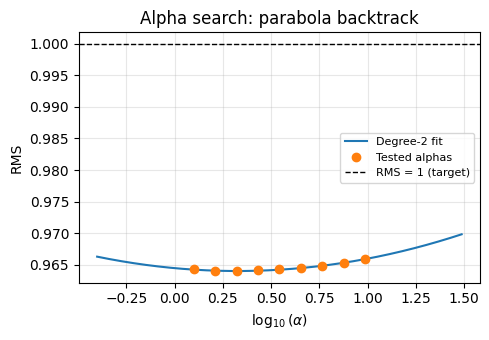

    Best Data Misfit: 0.9659

CONVERGENCE ACHIEVED: RMS < 1.

TOTAL INVERSION TIME: 5.27 seconds
FINAL DATA MISFIT: 0.966


In [ ]:
log_resistivities = np.ones_like(thicknesses) * np.log(100.0)

best_rho, mod_data, iter_rms_list, iter_roughness_list, rho_hist = invert(
    obs_data=obs_data,
    thicknesses=thicknesses,
    log_resistivities=log_resistivities,
    tx_radius=a,
    times=times,
    alpha_steps=10,
    maxit=10,
    eps=1e-4,
    noise_std=noise_std,
    use_cuda=True,
    calc_sens=False,
    transform='euler',
    hankel_filter='key_101',
    fourier_filter='key_81',
    max_noise_frac=0.02,
    plot_alpha=True,
    analytical_j=False
)


## 7. Results

Summary plots: data fit, RMS convergence history, and recovered resistivity model vs true model.

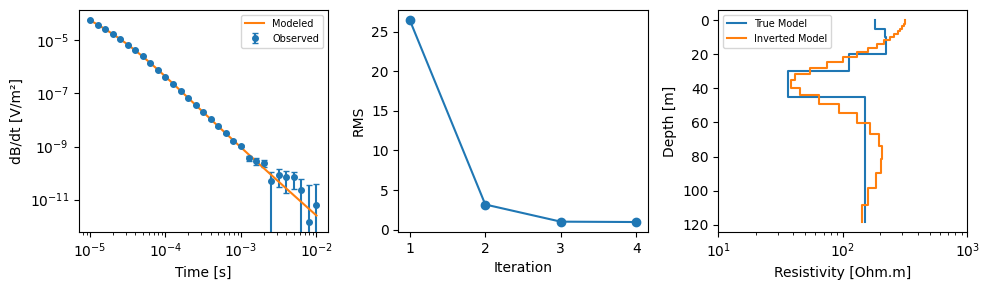

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

axs[0].errorbar(times, obs_data, yerr=noise_std, fmt='o', markersize=4, capsize=2, label='Observed')
axs[0].loglog(times, mod_data, '-', label='Modeled', markersize=4)
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('dB/dt [V/m²]')
axs[0].legend(fontsize=7)

axs[1].plot(range(1, len(iter_rms_list) + 1), iter_rms_list, 'o-')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('RMS')

depths0 = np.cumsum(np.concatenate(([0], thicknesses0[:-1])))
axs[2].step(np.r_[rho0, rho0[-1]], np.r_[depths0, depths[-1]+10], where='pre', label='True Model')
depths = np.cumsum(np.concatenate(([0], thicknesses[:-1])))
axs[2].step(np.r_[best_rho, best_rho[-1]], np.r_[depths, depths[-1]+10], where='pre', label='Inverted Model')

axs[2].invert_yaxis()
axs[2].set_xlabel('Resistivity [Ohm.m]')
axs[2].set_ylabel('Depth [m]')
axs[2].set_xscale('log')
axs[2].legend(fontsize=7)
axs[2].set_xlim(10, 1000)

fig.tight_layout()